In [1]:
import numpy as np
import matplotlib.pyplot as plt

First of all we create functions for Gauss quadratic formula for 2, 4, and 6 points.

In [2]:
def gauss_2_points(a, b, fs):
  nodes = np.array([-np.sqrt(1.0 / 3.0), np.sqrt(1.0 / 3.0)])
  weights = np.array([1.0, 1.0])

  integral = 0.0

  for i in range(2):
        x = 0.5 * ((b - a) * nodes[i] + (b + a))
        integral = integral + weights[i] * fs(x)

  integral = integral * 0.5 * (b - a)
  return integral

In [3]:
def gauss_4_points(a,b,fs):
  nodes = np.array([-np.sqrt((3 + 2 * np.sqrt(6/5)) / 7),
        -np.sqrt((3 - 2 * np.sqrt(6/5)) / 7),
         np.sqrt((3 - 2 * np.sqrt(6/5)) / 7),
         np.sqrt((3 + 2 * np.sqrt(6/5)) / 7)])
  weights = np.array([((18 - np.sqrt(30)) / 36),
        ((18 + np.sqrt(30)) / 36),
        ((18 + np.sqrt(30)) / 36),
        ((18 - np.sqrt(30)) / 36)])

  integral = 0.0

  for i in range(4):
        x = (0.5) * ((b - a) * nodes[i] + (b + a))
        integral = integral + (weights[i] * fs(x))

  integral = integral * 0.5 * (b-a)

  return integral

In [4]:
def gauss_6_points(a,b,fs):
  nodes = np.array([-0.9324695142031521,
          -0.6612093864662645,
          -0.2386191860831969,
          0.2386191860831969,
          0.6612093864662645,
          0.9324695142031521])
  weights = np.array([0.1713244923791703,
                        0.3607615730481386,
                        0.4679139345726910,
                        0.4679139345726910,
                        0.3607615730481386,
                        0.1713244923791703])

  integral = 0.0

  for i in range(6):
        x = (0.5) * ((b - a) * nodes[i] + (b + a))
        integral = integral + (weights[i] * fs(x))

  integral = integral * 0.5 * (b-a)

  return integral

Then we create a function for trapezoidal rule and the function we will use to test these methods

In [19]:
def trapezoid(a,b,n,fs):
  h = (b-a)/n

  r = 0.0

  for i in range (1,n):
    r = r + fs(a+i*h)

  result = (r + (fs(a) + fs(b)) / 2.0) * h

  return result

In [20]:
def f(x):
  f2 = 2* np.sin(x- np.pi/4)+3
  return f2

In [34]:
end = (4*np.pi)
n_values = np.arange(0,end,0.3)

In [35]:
gauss_2_points(0,end,f),gauss_4_points(0,end,f),gauss_6_points(0,end,f),trapezoid(0,end,1,f),trapezoid(0,end,2,f),trapezoid(0,end,3,f)

(np.float64(53.412797268041466),
 np.float64(39.93356719202404),
 np.float64(37.72438988004571),
 np.float64(19.927580090444042),
 np.float64(19.927580090444046),
 np.float64(37.69911184307752))

At last we plot the original graph and how our methods "predict"the function

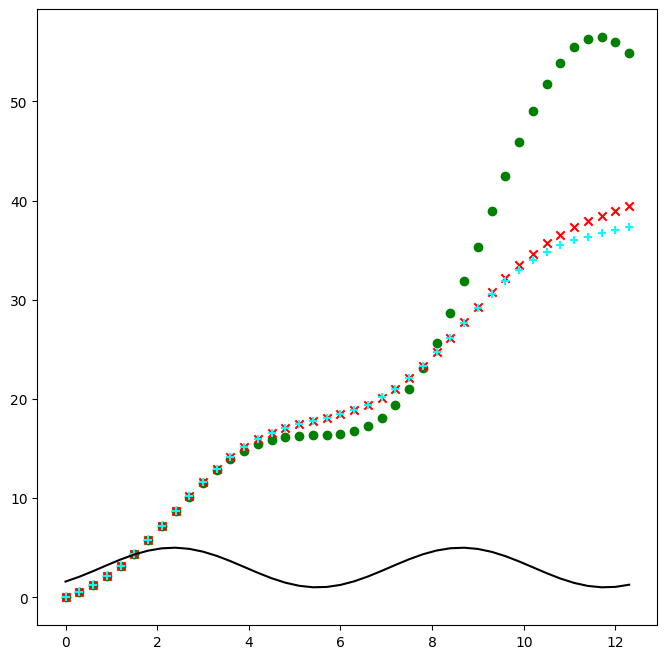

In [36]:
plt.figure(figsize=(8,8))
plt.plot(n_values,f(n_values),color = 'black')
plt.scatter(n_values,gauss_2_points(0,n_values,f),color='green',marker='o')
plt.scatter(n_values,gauss_4_points(0,n_values,f),color='red', marker = 'x')
plt.scatter(n_values,gauss_6_points(0,n_values,f),color='cyan',marker = '+')
plt.show()

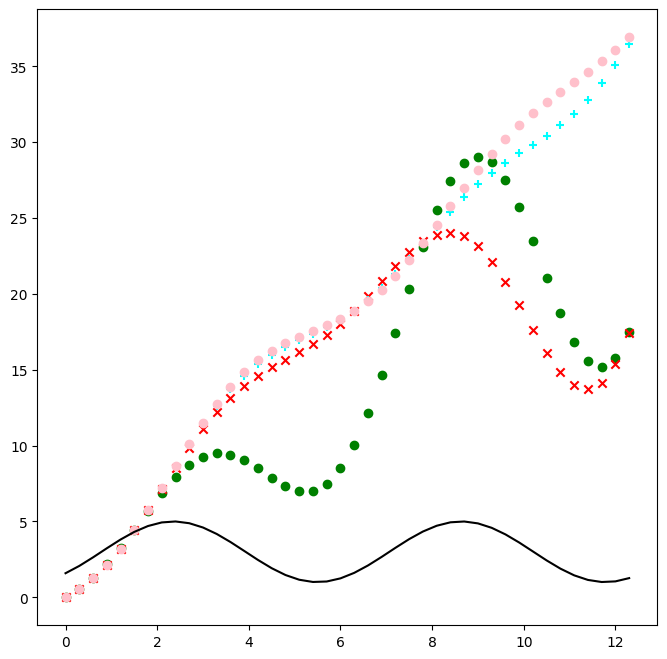

In [37]:
plt.figure(figsize=(8,8))
plt.plot(n_values,f(n_values),color = 'black')
plt.scatter(n_values,trapezoid(0,n_values,1,f),color='green',marker='o')
plt.scatter(n_values,trapezoid(0,n_values,2,f),color='red', marker = 'x')
plt.scatter(n_values,trapezoid(0,n_values,3,f),color='cyan',marker = '+')
plt.scatter(n_values,trapezoid(0,n_values,4,f),color='pink',marker = 'o')
plt.show()